<a href="https://colab.research.google.com/github/Ifeoluwakareem/IFEOLUWA_ML/blob/main/Python_basics_01/tensors_fundamental/Neural_Network_Regression_with_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **What we're going to cover**
Specifically, we're going to go through doing the following with TensorFlow:

Architecture of a regression model
Input shapes and output shapes
X: features/data (inputs)
y: labels (outputs)
Creating custom data to view and fit
Steps in modelling
Creating a model
Compiling a model
Defining a loss function
Setting up an optimizer
Creating evaluation metrics
Fitting a model (getting it to find patterns in our data)
Evaluating a model
Visualizng the model ("visualize, visualize, visualize")
Looking at training curves
Compare predictions to ground truth (using our evaluation metrics)
Saving a model (so we can use it later)
Loading a model
Don't worry if none of these make sense now, we're going to go through

In [1]:
# Regression problem simply means predicting a number eg. Predict the selling price of houses given information about them (such as number of rooms, size, number of bathrooms).
import tensorflow as tf
print(tf.__version__) # check the version (should be 2.x+)

import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

2.20.0
Notebook last run (end-to-end): 2026-06-22 15:00:45.525942


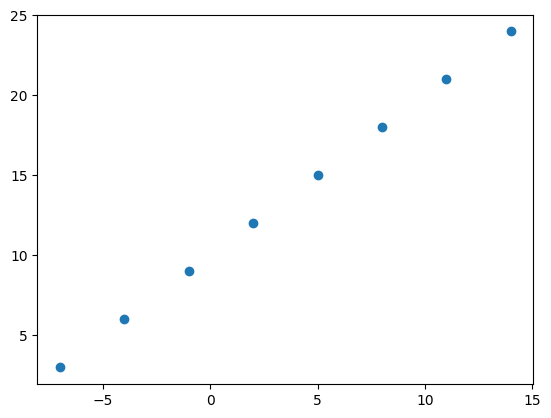

In [7]:
# Creating data to view and fit

import numpy as np
import matplotlib.pyplot as plt

## Create features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y);

# **Regression input shapes and output shapes**

The input shape is the shape of your data that goes into the model.
The output shape is the shape of your data you want to come out of your model.

Neural networks accept numbers and output numbers. These numbers are typically represented as tensors (or arrays).

In [2]:
# Example input and output shapes of a regression model
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price


(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [3]:
house_info.shape

TensorShape([3])

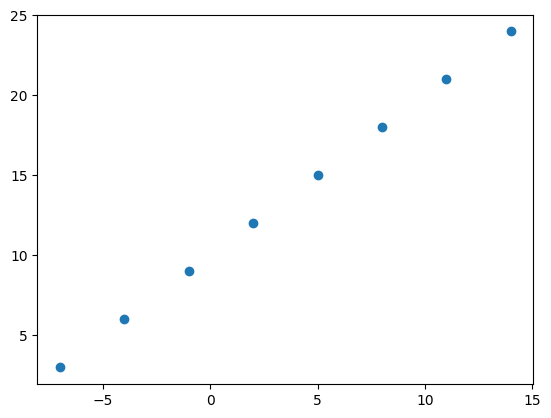

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Create features (using tensors)
X = tf.constant([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels (using tensors)
y = tf.constant([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y);



In [5]:
# Take a single example of X
input_shape = X[0].shape

# Take a single example of y
output_shape = y[0].shape

input_shape, output_shape # these are both scalars (no shape)

# From this it seems our inputs and outputs have no shape?
# How could that be?
# It's because no matter what kind of data we pass to our model, it's always going to take as input and return as output some kind of tensor.
# But in our case because of our dataset (only 2 small lists of numbers), we're looking at a special kind of tensor, more specifically a rank 0 tensor or a scalar.


(TensorShape([]), TensorShape([]))

In [6]:
# Let's take a look at the single examples invidually
X[0], y[0]


(<tf.Tensor: shape=(), dtype=float32, numpy=-7.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=3.0>)

If you were working on building a machine learning algorithm for predicting housing prices, your inputs may be number of bedrooms, number of bathrooms and number of garages, giving you an input shape of 3 (3 different features). And since you're trying to predict the price of the house, your output shape would be 1.

### **Steps in modelling with TensorFlow**
In TensorFlow, there are typically 3 fundamental steps to creating and training a model.

1. Creating a model - piece together the layers of a neural network yourself (using the Functional or Sequential API) or import a previously built model (known as transfer learning).
2. Compiling a model - defining how a models performance should be measured (loss/metrics) as well as defining how it should improve (optimizer).
3. Fitting a model - letting the model try to find patterns in the data (how does X get to y).

**Note**: If you're using TensorFlow 2.7.0+, the fit() function no longer upscales input data to go from (batch_size, ) to (batch_size, 1). To fix this, you'll need to expand the dimension of input data using tf.expand_dims(input_data, axis=-1).

In our case, this means instead of using model.fit(X, y, epochs=5), use model.fit(tf.expand_dims(X, axis=-1), y, epochs=5).